In [ ]:
import os
import glob
from pathlib import Path

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# PlanetScope PSScene folder path
folder = r"C:\Users\ahtrabelsi\Downloads\beetsat_psscene_analytic_sr_udm2\PSScene"

files = glob.glob(os.path.join(folder, "*AnalyticMS_SR_clip.tif"))

print(f"Found {len(files)} images")

Found 19 images


In [10]:
image_info = []

for f in files:
    name = Path(f).name

    date_str = name[:8]
    date = datetime.strptime(date_str, "%Y%m%d")

    image_info.append((date, f))

# sort by date
image_info.sort()

for date, f in image_info:
    print(date.date(), Path(f).name)

2020-01-21 20200121_104621_88_1064_3B_AnalyticMS_SR_clip.tif
2020-01-21 20200121_104623_89_1064_3B_AnalyticMS_SR_clip.tif
2020-02-18 20200218_100828_44_106b_3B_AnalyticMS_SR_clip.tif
2020-02-18 20200218_100830_48_106b_3B_AnalyticMS_SR_clip.tif
2020-04-20 20200420_103615_28_105c_3B_AnalyticMS_SR_clip.tif
2020-04-20 20200420_103617_77_105c_3B_AnalyticMS_SR_clip.tif
2020-05-06 20200506_100446_61_106b_3B_AnalyticMS_SR_clip.tif
2020-05-06 20200506_100448_15_106b_3B_AnalyticMS_SR_clip.tif
2020-05-06 20200506_100449_69_106b_3B_AnalyticMS_SR_clip.tif
2020-06-25 20200625_095650_96_2271_3B_AnalyticMS_SR_clip.tif
2020-07-21 20200721_100324_0e26_3B_AnalyticMS_SR_clip.tif
2020-07-21 20200721_100325_0e26_3B_AnalyticMS_SR_clip.tif
2020-08-08 20200808_095834_39_2206_3B_AnalyticMS_SR_clip.tif
2020-09-14 20200914_095630_82_1062_3B_AnalyticMS_SR_clip.tif
2020-09-14 20200914_095632_86_1062_3B_AnalyticMS_SR_clip.tif
2020-10-31 20201031_102526_1009_3B_AnalyticMS_SR_clip.tif
2020-10-31 20201031_102527_1009_3

In [11]:
def read_planetscope(tif_path, scale_factor=10000):
    """
    Read PlanetScope SR image and convert DN to reflectance.
    """

    with rasterio.open(tif_path) as src:
        image = src.read().astype(np.float32)
        profile = src.profile

    image /= scale_factor

    return image, profile

def show_metadata(profile):
    print("Width:", profile["width"])
    print("Height:", profile["height"])
    print("Bands:", profile["count"])
    print("Data type:", profile["dtype"])
    print("CRS:", profile["crs"])
    print("Transform:")
    print(profile["transform"])


def show_bands(image):

    names = ["Blue", "Green", "Red", "NIR"]

    fig, axes = plt.subplots(1,4, figsize=(18,5))

    for i in range(4):
        ax = axes[i]

        im = ax.imshow(image[i], cmap='gray')

        ax.set_title(names[i])
        ax.axis('off')

        plt.colorbar(im, ax=ax)

    plt.tight_layout()

def band_statistics(image):

    names = ["Blue", "Green", "Red", "NIR"]

    for i in range(4):

        band = image[i]

        print(f"\n{names[i]}")
        print("Min :", np.nanmin(band))
        print("Max :", np.nanmax(band))
        print("Mean:", np.nanmean(band))
        print("Std :", np.nanstd(band))


def show_histograms(image, bins=300,
                    lower_percentile=0.5,
                    upper_percentile=99.5):

    names = ["Blue", "Green", "Red", "NIR"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.ravel()

    for i in range(4):

        band = image[i]

        # Remove NaN and invalid values
        band = band[np.isfinite(band)]

        # Compute percentiles for visualization
        p_low, p_high = np.percentile(
            band,
            [lower_percentile, upper_percentile]
        )

        # Keep only the central distribution
        band_vis = band[(band >= p_low) & (band <= p_high)]

        mean_val = np.mean(band_vis)
        median_val = np.median(band_vis)

        axes[i].hist(
            band_vis,
            bins=bins,
            density=True,
            alpha=0.7
        )


        axes[i].set_title(names[i], fontsize=14)
        axes[i].set_xlabel("Reflectance")
        axes[i].set_ylabel("Density")
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

def show_rgb_raw(image):
    rgb = np.dstack([image[2], image[1], image[0]])

    p2,p98 = np.nanpercentile(rgb,(2,98))
    rgb = np.clip((rgb-p2)/(p98-p2),0,1)
    plt.figure(figsize=(8,8))
    plt.imshow(rgb)
    plt.axis("off")

In [12]:
images = []
for date, f in image_info:
    img, profile = read_planetscope(f)
    images.append({"img":img,"profile":profile})

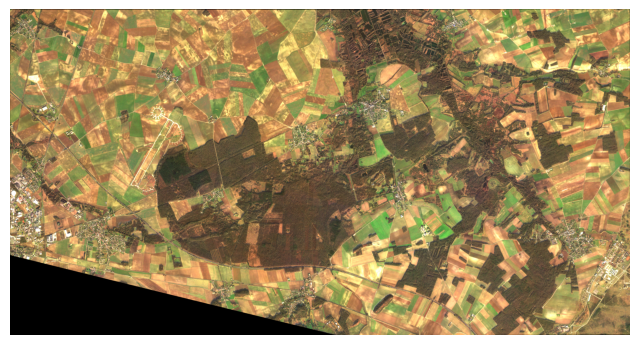

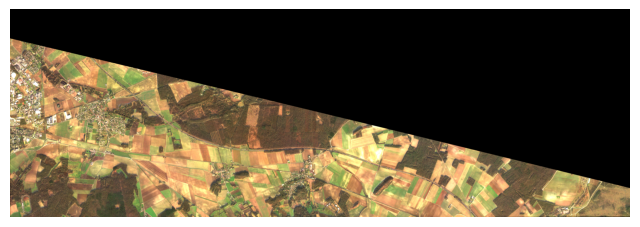

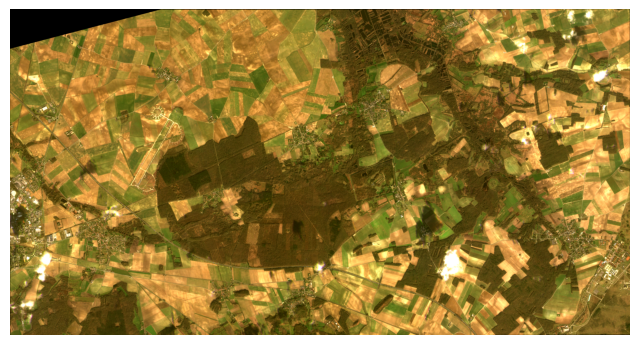

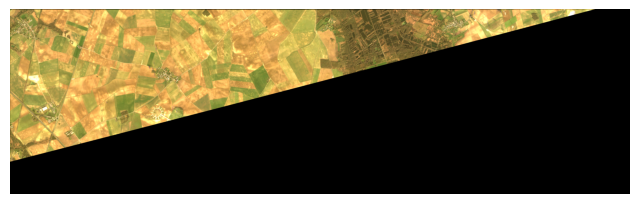

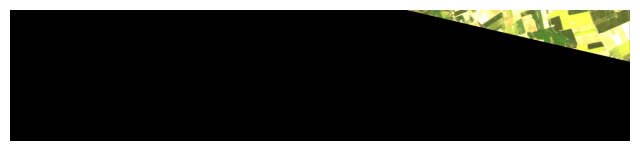

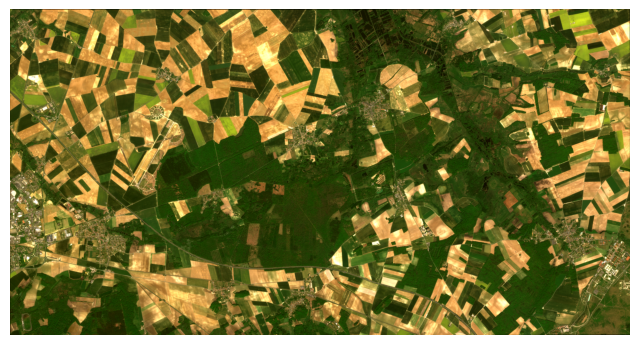

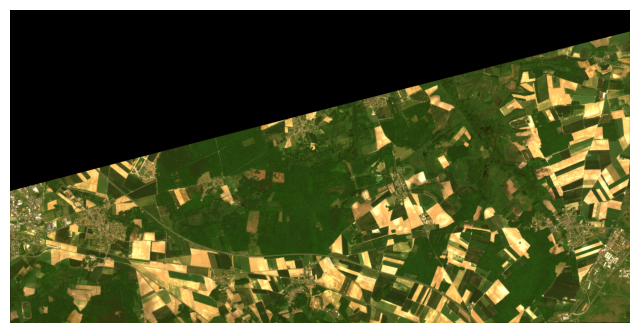

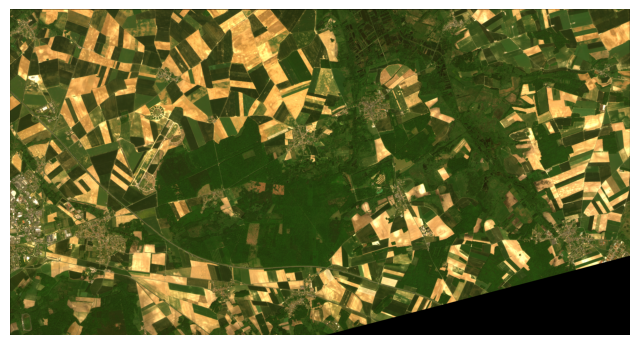

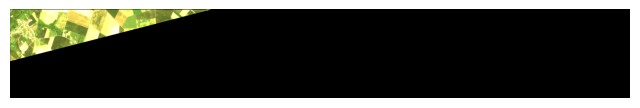

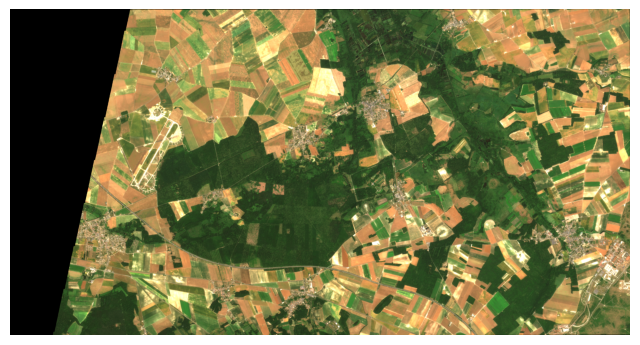

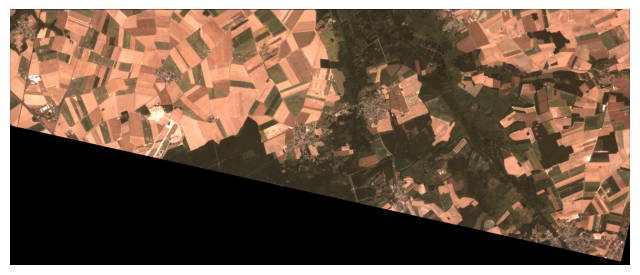

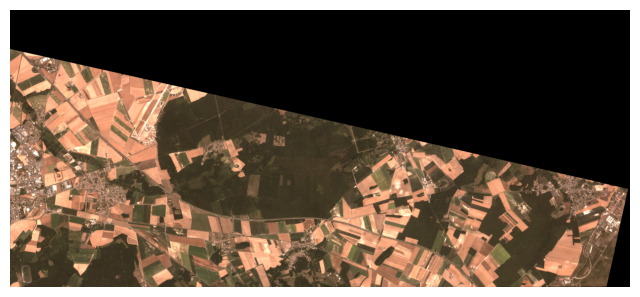

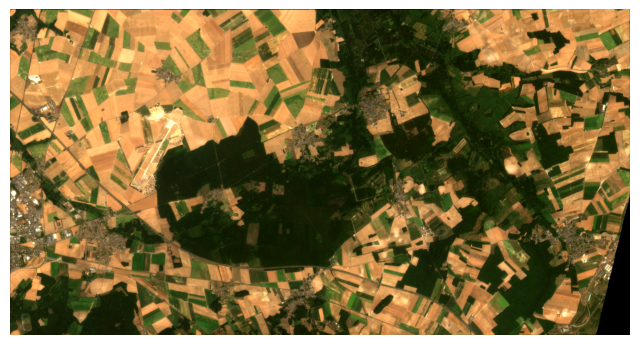

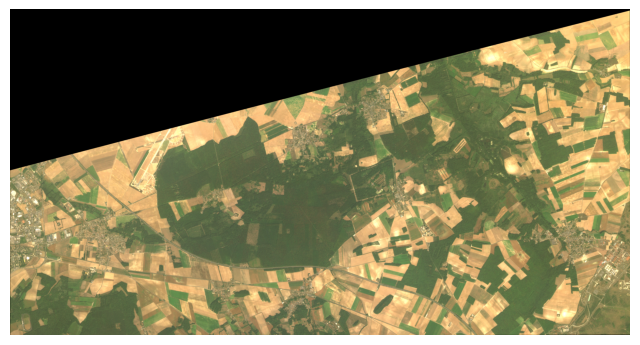

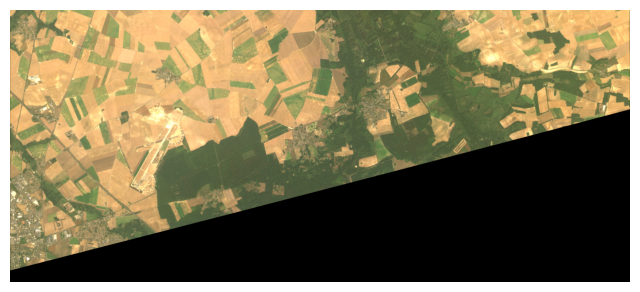

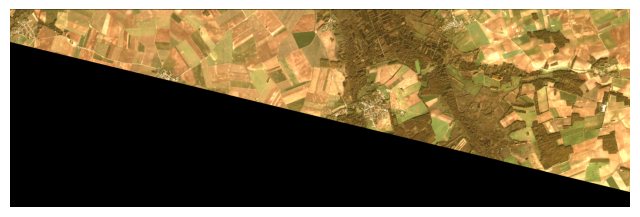

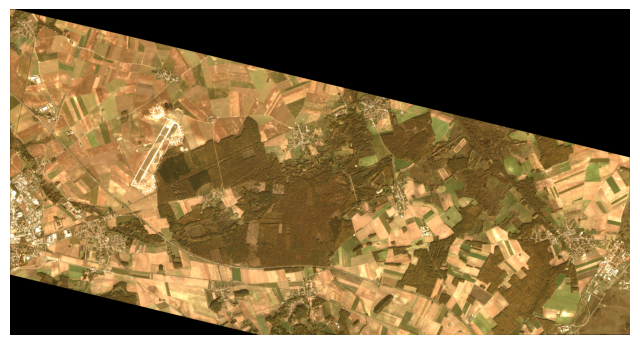

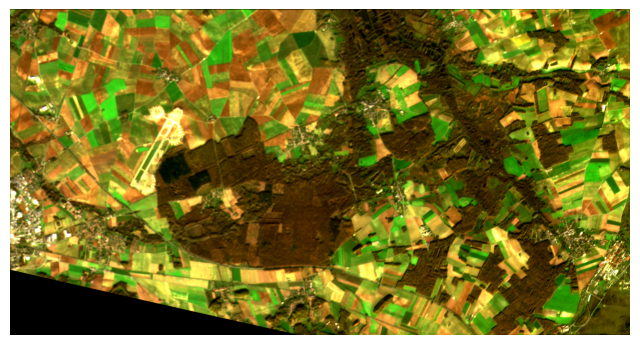

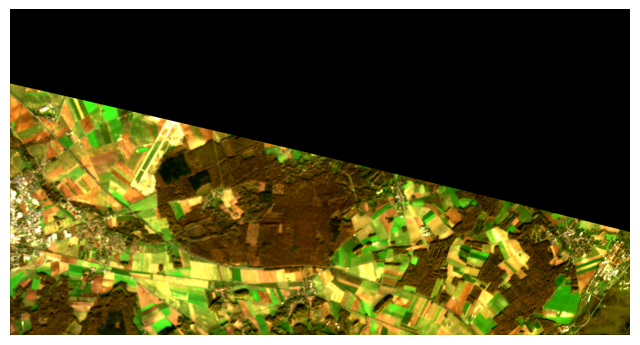

In [13]:
for item in images:
    show_rgb_raw(item['img'])